### EDA

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import autocorrelation_plot
plt.style.use("ggplot")

C:\Users\48661\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Data upload
df = pd.read_csv("../data/raw/hour.csv")

In [3]:
# Data preview
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


#### Data description

## Dataset Description

The dataset comes from the UCI Machine Learning Repository Bike Sharing Dataset:
https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

It contains hourly records of bike rental demand together with weather and calendar-related features collected in Washington D.C. during 2011–2012.

The main prediction target is:

- `cnt` — total number of rented bikes per hour.

### Feature Description

| Feature | Description |
|---|---|
| instant | Record index |
| dteday | Date |
| season | Season category (1: winter, 2: spring, 3: summer, 4: fall) |
| yr | Year (0: 2011, 1: 2012) |
| mnth | Month (1–12) |
| hr | Hour of the day (0–23) |
| holiday | Whether the day is a holiday |
| weekday | Day of the week |
| workingday | 1 if neither weekend nor holiday, otherwise 0 |
| weathersit | Weather situation category |
| temp | Normalized temperature in Celsius |
| atemp | Normalized feeling temperature in Celsius |
| hum | Normalized humidity |
| windspeed | Normalized wind speed |
| casual | Number of casual users |
| registered | Number of registered users |
| cnt | Total bike rentals (`casual + registered`) |

### Weather Situation Encoding

| Value | Description |
|---|---|
| 1 | Clear, few clouds, partly cloudy |
| 2 | Mist + cloudy |
| 3 | Light snow or light rain with clouds |
| 4 | Heavy rain, snow, fog, thunderstorm |

### Notes

- Temperature, humidity and wind speed are normalized variables.
- The dataset does not contain missing values.
- The target variable for forecasting tasks is `cnt`.

In [4]:
df.shape

(17379, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [7]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [11]:
df.duplicated().sum()

0

 Dataset contains hourly bike rental observations with weather and seasonal variables. No missing values  or duplicates were detected.

### Datetime parsing

In [8]:
df["datetime"] = (
    pd.to_datetime(df["dteday"])
    + pd.to_timedelta(df["hr"], unit="h")
)

In [9]:
df = df.sort_values("datetime")

In [10]:
df = df.set_index("datetime")

### Frequency continuity check

In [13]:
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="H"
)

missing_timestamps = full_range.difference(df.index)

len(missing_timestamps)

C:\Users\48661\AppData\Local\Temp\ipykernel_21660\4178275325.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(


165

In [15]:
missing_timestamps[:40]

DatetimeIndex(['2011-01-02 05:00:00', '2011-01-03 02:00:00',
               '2011-01-03 03:00:00', '2011-01-04 03:00:00',
               '2011-01-05 03:00:00', '2011-01-06 03:00:00',
               '2011-01-07 03:00:00', '2011-01-11 03:00:00',
               '2011-01-11 04:00:00', '2011-01-12 03:00:00',
               '2011-01-12 04:00:00', '2011-01-14 04:00:00',
               '2011-01-18 00:00:00', '2011-01-18 01:00:00',
               '2011-01-18 02:00:00', '2011-01-18 03:00:00',
               '2011-01-18 04:00:00', '2011-01-18 05:00:00',
               '2011-01-18 06:00:00', '2011-01-18 07:00:00',
               '2011-01-18 08:00:00', '2011-01-18 09:00:00',
               '2011-01-18 10:00:00', '2011-01-18 11:00:00',
               '2011-01-19 03:00:00', '2011-01-22 05:00:00',
               '2011-01-23 04:00:00', '2011-01-24 02:00:00',
               '2011-01-25 03:00:00', '2011-01-26 03:00:00',
               '2011-01-26 04:00:00', '2011-01-26 18:00:00',
               '2011-01-

In [16]:
missing_timestamps.to_series().diff().value_counts()

0 days 01:00:00      90
0 days 23:00:00      11
1 days 00:00:00      10
2 days 01:00:00       4
0 days 21:00:00       3
1 days 01:00:00       3
1 days 22:00:00       3
2 days 00:00:00       3
4 days 01:00:00       2
200 days 21:00:00     1
7 days 00:00:00       1
37 days 00:00:00      1
21 days 00:00:00      1
39 days 23:00:00      1
27 days 02:00:00      1
4 days 23:00:00       1
8 days 00:00:00       1
20 days 00:00:00      1
9 days 01:00:00       1
14 days 01:00:00      1
138 days 15:00:00     1
8 days 01:00:00       1
10 days 22:00:00      1
8 days 15:00:00       1
22 days 01:00:00      1
8 days 19:00:00       1
2 days 02:00:00       1
13 days 23:00:00      1
0 days 13:00:00       1
4 days 00:00:00       1
3 days 20:00:00       1
0 days 16:00:00       1
3 days 02:00:00       1
0 days 22:00:00       1
0 days 14:00:00       1
5 days 00:00:00       1
3 days 00:00:00       1
4 days 03:00:00       1
1 days 19:00:00       1
0 days 02:00:00       1
6 days 01:00:00       1
3 days 01:00:00 

The dataset contains irregular missing hourly observations.
Most missing timestamps are isolated single-hour gaps, although several longer gaps are also present.

Because the proportion of missing timestamps is relatively small compared to the full dataset, no interpolation or synthetic observations were introduced.
The original temporal structure of the dataset was preserved.

## Global Exploratory Data Analysis

At this stage, exploratory data analysis is performed on the full dataset in order to understand:
- the overall structure of the data,
- temporal patterns,
- seasonality,
- weather effects,
- and potential data quality issues.

This global analysis is used only for descriptive and exploratory purposes and does not involve:
- feature engineering,
- lag construction,
- hyperparameter tuning,
- or model fitting.

We do not  want to introduce data leakage into the forecasting pipeline.

More model-oriented analysis (e.g. lag selection and autocorrelation analysis) will later be performed exclusively on the training subset.

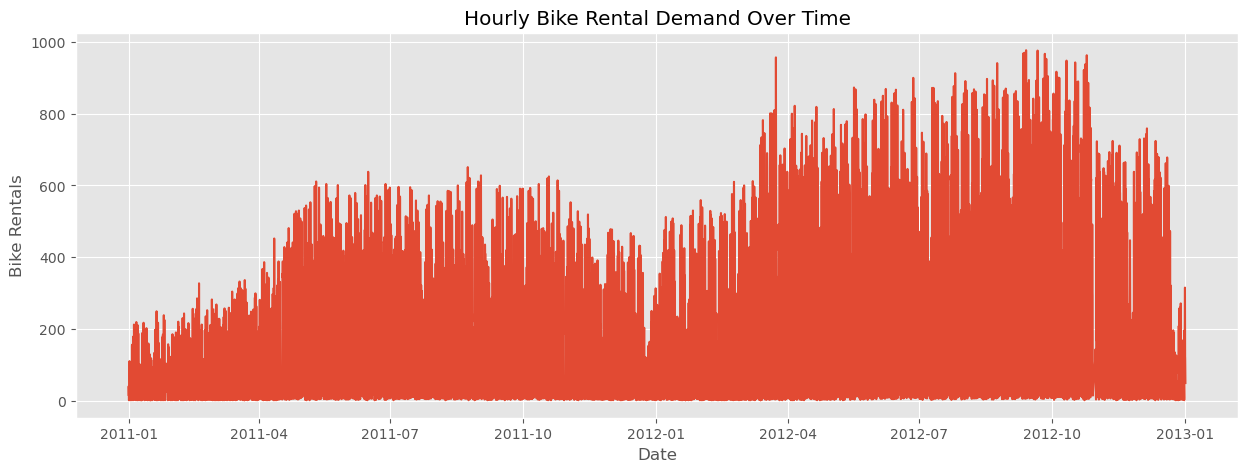

In [18]:
# Target trend
plt.figure(figsize=(15,5))

plt.plot(df.index, df["cnt"])

plt.title("Hourly Bike Rental Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Bike Rentals")

plt.show()

C:\Users\48661\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


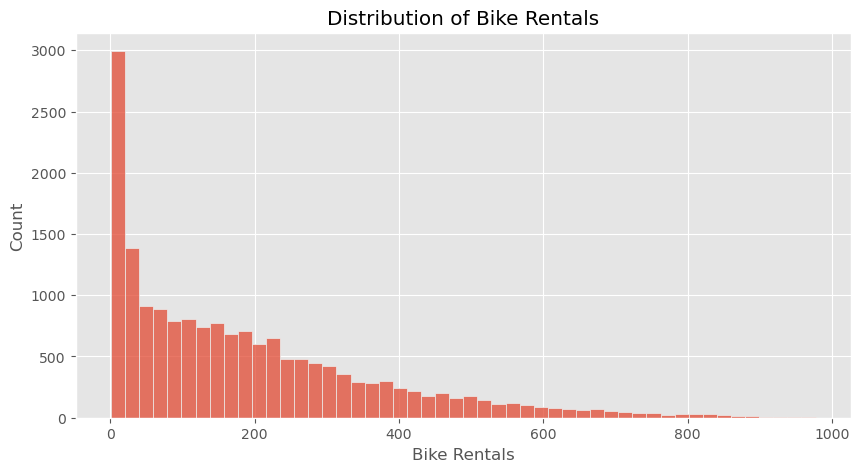

In [19]:
# Target distribution
plt.figure(figsize=(10,5))

sns.histplot(df["cnt"], bins=50)

plt.title("Distribution of Bike Rentals")
plt.xlabel("Bike Rentals")

plt.show()

The target distribution is right-skewed, with many low-demand periods and several high-demand peaks.
This behavior is typical for urban mobility demand data.

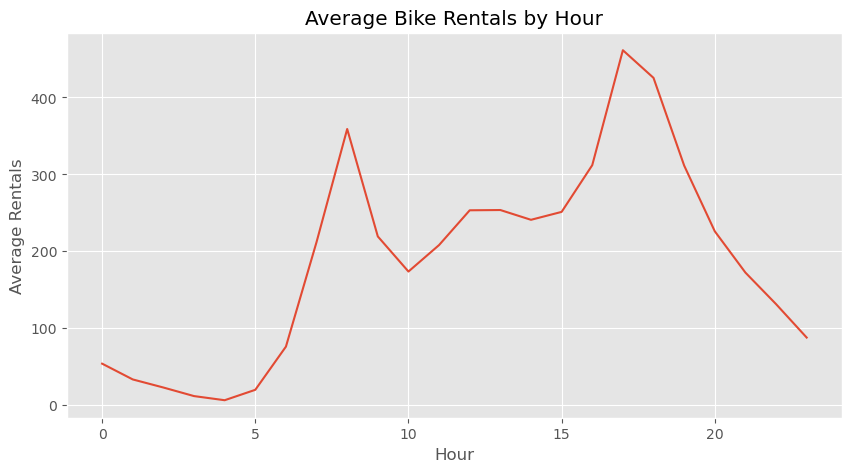

In [20]:
# Rentals by hour
hourly_avg = df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(10,5))

hourly_avg.plot()

plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")

plt.show()

Two clear demand peaks are visible during commuting hours, suggesting strong daily seasonality.

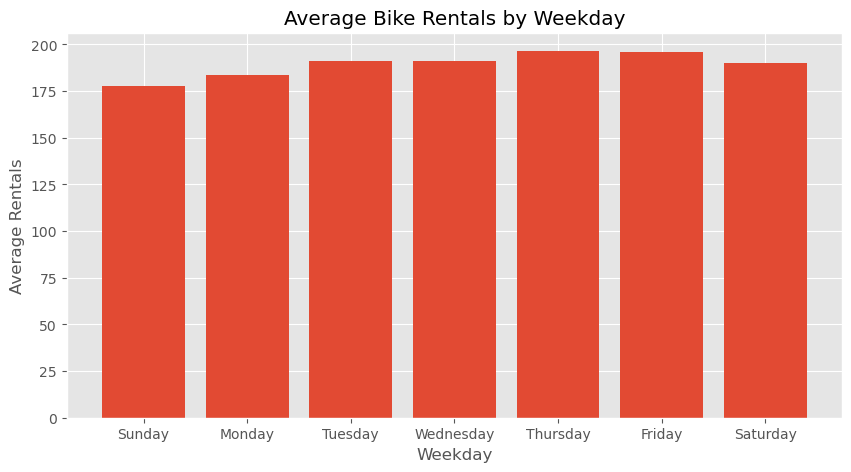

In [26]:
# Rental by weekday
weekday_avg = df.groupby("weekday")["cnt"].mean()

weekday_names = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

plt.figure(figsize=(10,5))

plt.bar(weekday_names, weekday_avg)

plt.title("Average Bike Rentals by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Rentals")

plt.show()

Average bike rental demand remains relatively stable across weekdays, although slightly higher activity can be observed during the middle and end of the workweek.

This suggests that weekly seasonality exists, but is weaker than the daily seasonal patterns observed previously.

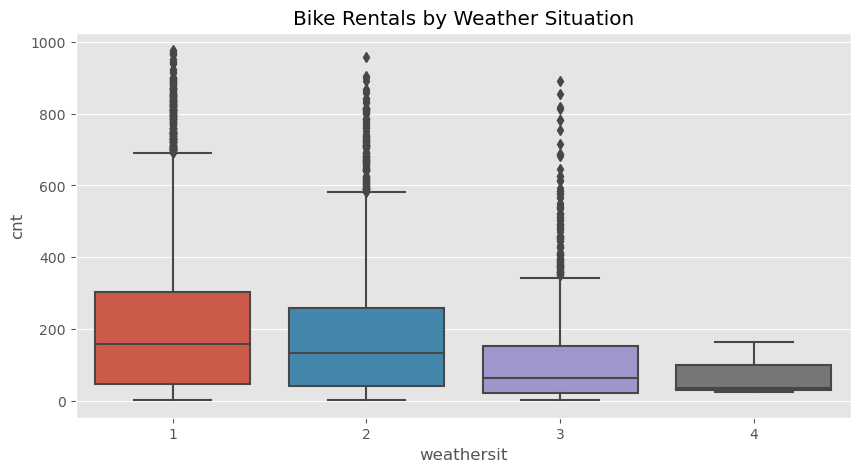

In [22]:
# Weather impact
plt.figure(figsize=(10,5))

sns.boxplot(x="weathersit", y="cnt", data=df)

plt.title("Bike Rentals by Weather Situation")

plt.show()

Bike rental demand decreases noticeably under worse weather conditions.

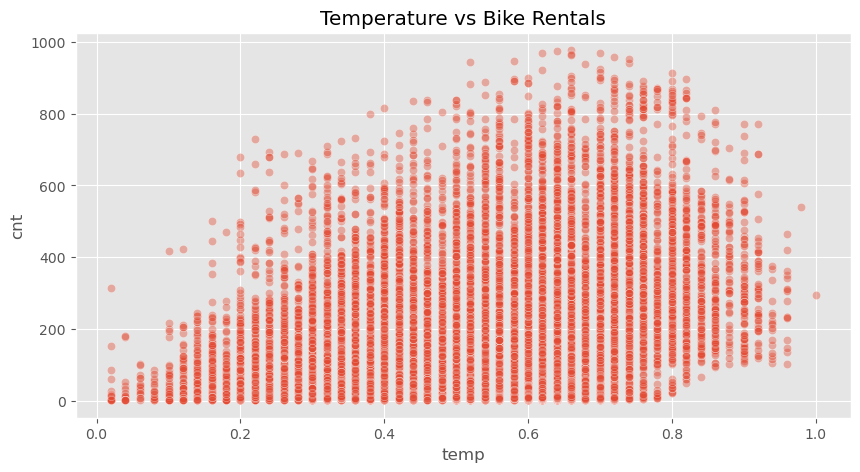

In [23]:
# Temperature impact
plt.figure(figsize=(10,5))

sns.scatterplot(x="temp", y="cnt", data=df, alpha=0.4)

plt.title("Temperature vs Bike Rentals")

plt.show()

Higher temperatures are generally associated with increased bike rental demand.

### Correlation matrix

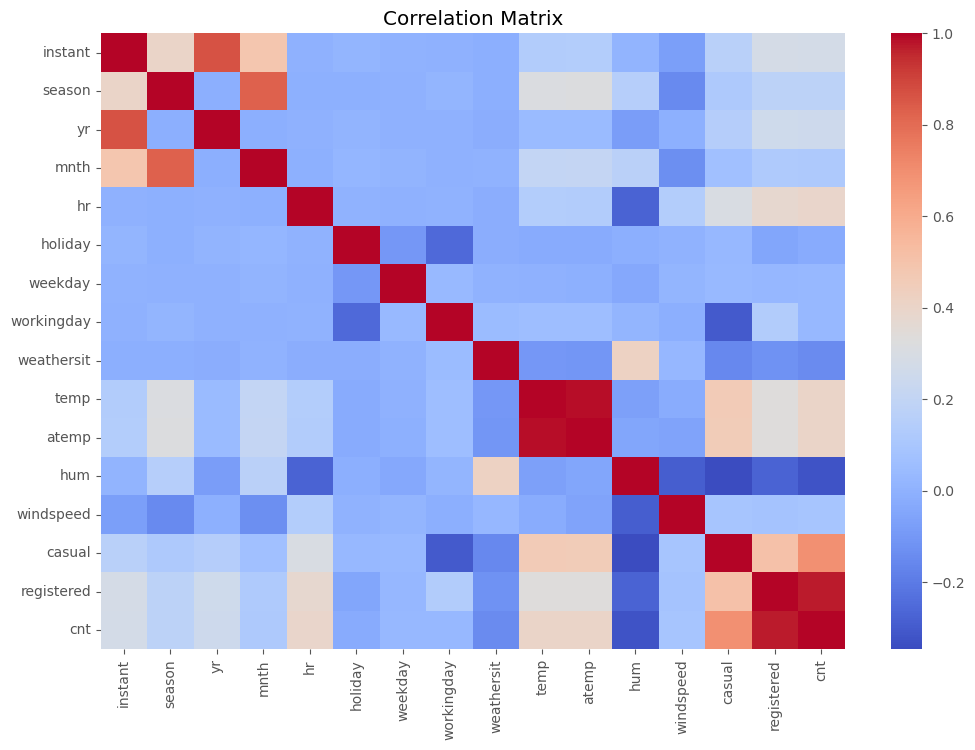

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

### Correlation Analysis

The correlation matrix reveals several important relationships within the dataset.

The strongest positive correlations with the target variable (`cnt`) are observed for:
- `registered`,
- `casual`,
- `temp`,
- and `atemp`.

As expected, `casual` and `registered` are highly correlated with `cnt`, since the target variable is defined as their sum. These variables therefore introduce direct data leakage and must be excluded from forecasting models.

Temperature-related variables (`temp` and `atemp`) also show moderate positive correlations with bike rental demand, indicating that warmer weather generally increases rental activity.

Humidity (`hum`) and adverse weather conditions (`weathersit`) exhibit negative correlations with the target variable, suggesting that poor weather reduces bike usage.

Additionally, a very strong correlation exists between `temp` and `atemp`, indicating substantial multicollinearity between these variables.

In [27]:
corr_matrix = df.corr(numeric_only=True)

corr_pairs = corr_matrix.unstack()

strong_corr = corr_pairs[
    (abs(corr_pairs) > 0.7) &
    (abs(corr_pairs) < 1.0)
]

strong_corr = strong_corr.sort_values(
    ascending=False,
    key=lambda x: abs(x)
)

strong_corr = strong_corr[
    strong_corr.index.get_level_values(0)
    != strong_corr.index.get_level_values(1)
]

strong_corr = strong_corr.drop_duplicates()

strong_corr

temp        atemp    0.987672
registered  cnt      0.972151
instant     yr       0.866014
season      mnth     0.830386
dtype: float64

# Train validation test split 

#### 1. chronological order check
#### 2. leakage columns drop
#### 3. split 70/20/10
#### 4. splits check
#### 5. save splits

In [28]:
# chronological order check
df.index.is_monotonic_increasing

True

The dataset is correctly ordered chronologically and is suitable for time series forecasting tasks.

In [29]:
# removing leakage columns
model_df = df.drop(
    columns=[
        "instant",
        "casual",
        "registered",
        "atemp"
    ]
)

### Feature Selection and Leakage Prevention

Several preprocessing decisions were made before splitting the dataset into training, validation, and test subsets.

The variables `casual` and `registered` were removed because they directly contribute to the target variable `cnt`, which would introduce severe target leakage in forecasting models.

The `instant` variable was also removed since it acts only as a sequential row identifier and does not contain meaningful predictive information.

Additionally, the variables `temp` and `atemp` exhibit extremely high correlation, indicating strong multicollinearity. Since both variables represent similar temperature-related information, only `temp` was retained for further analysis and modeling.

In [30]:
model_df.columns

Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

## Train validation test split 70/20/10

In [32]:
n = len(model_df)

train_size = int(n * 0.7)
val_size = int(n * 0.2)

train = model_df.iloc[:train_size]
val = model_df.iloc[train_size:train_size + val_size]
test = model_df.iloc[train_size + val_size:]

In [33]:
# split size check
print(train.shape)
print(val.shape)
print(test.shape)

(12165, 13)
(3475, 13)
(1739, 13)


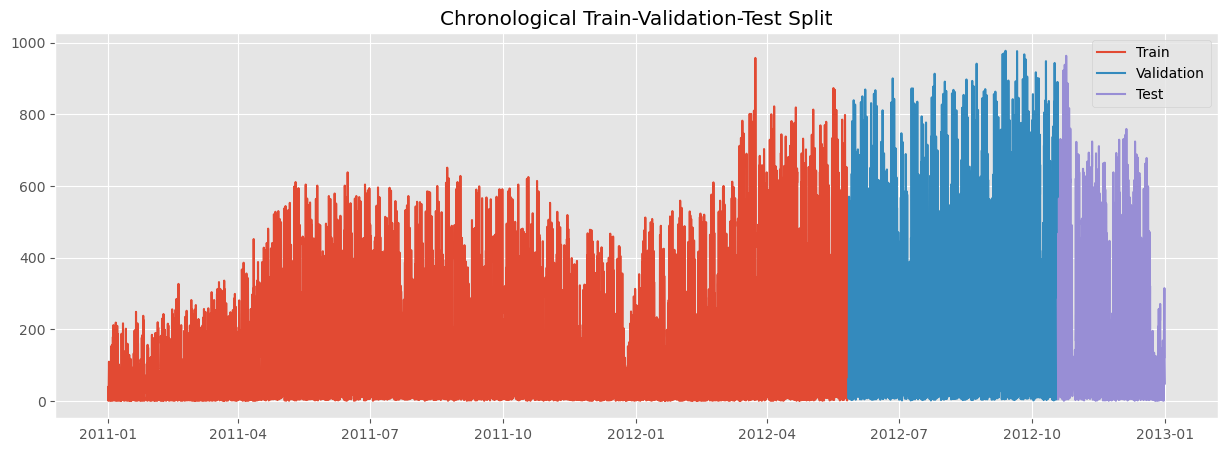

In [34]:
# split visualization
plt.figure(figsize=(15,5))

plt.plot(train.index, train["cnt"], label="Train")
plt.plot(val.index, val["cnt"], label="Validation")
plt.plot(test.index, test["cnt"], label="Test")

plt.legend()

plt.title("Chronological Train-Validation-Test Split")

plt.show()

The dataset was split chronologically to preserve the temporal ordering of observations and avoid future information leakage.

In [35]:
# splits saved
train.to_csv("../data/processed/train.csv")
val.to_csv("../data/processed/val.csv")
test.to_csv("../data/processed/test.csv")

# Forecasting-Oriented EDA on Training Set

The following analysis is performed exclusively on the training subset in order to better understand the temporal structure of the series before forecasting model development.

This section focuses on:
- trend analysis,
- seasonality inspection,
- temporal demand patterns,
- and general autocorrelation behavior.

No feature engineering or lag selection decisions are made at this stage.

In [36]:
# train dataset upload
train = pd.read_csv(
    "../data/processed/train.csv",
    index_col=0,
    parse_dates=True
)

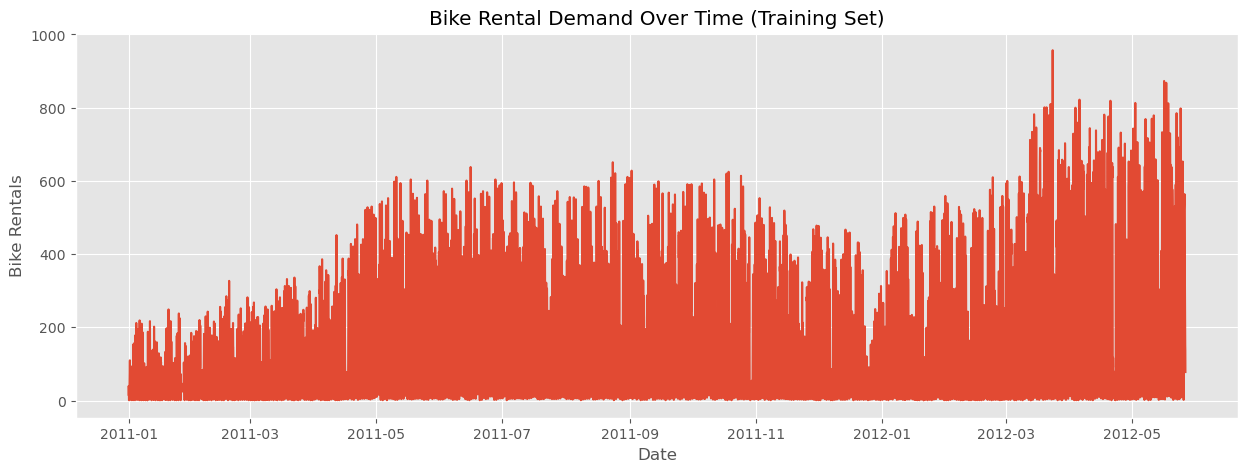

In [37]:
# Rentals over time
plt.figure(figsize=(15,5))

plt.plot(train.index, train["cnt"])

plt.title("Bike Rental Demand Over Time (Training Set)")
plt.xlabel("Date")
plt.ylabel("Bike Rentals")

plt.show()

The training series exhibits strong temporal variability together with visible recurring demand cycles, suggesting the presence of pronounced seasonality in bike rental demand.

An overall upward trend can also be observed between 2011 and 2012, indicating growing bike-sharing usage over time. Demand levels are noticeably lower during winter periods and substantially higher during warmer months, highlighting the influence of seasonal weather conditions.

Additionally, the series contains frequent short-term fluctuations and sharp peaks, which are characteristic of hourly urban mobility data.

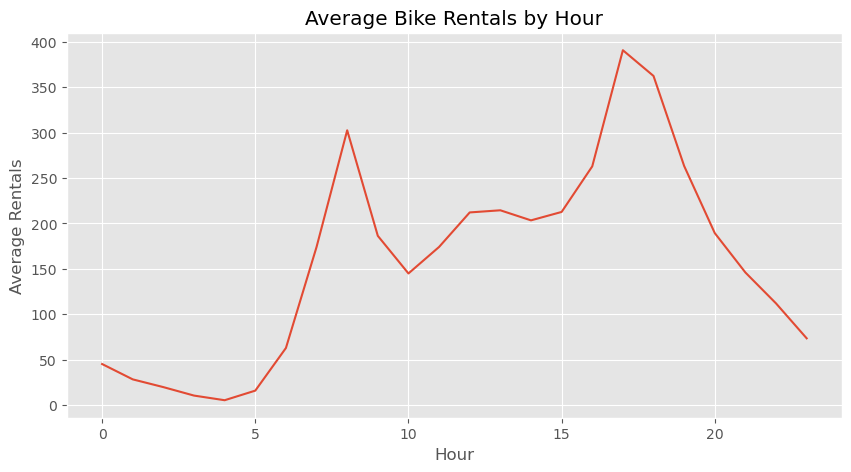

In [38]:
# Average rentals by hours
hourly_avg = train.groupby("hr")["cnt"].mean()

weekday_names = list(range(24))

plt.figure(figsize=(10,5))

plt.plot(hourly_avg)

plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")

plt.show()

Strong intra-day seasonality is clearly visible in the training data. Bike rental demand remains very low during nighttime hours and increases sharply during typical commuting periods.

Two pronounced demand peaks can be observed:
- a morning peak around 8:00,
- and a stronger evening peak around 17:00–18:00.

This pattern suggests that bike-sharing usage is strongly associated with daily commuting behavior and regular urban mobility routines.

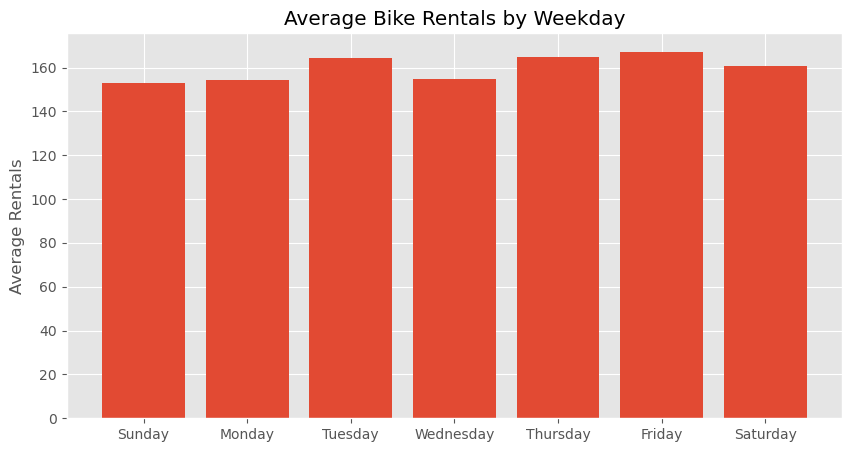

In [39]:
# Rentals by weekday
weekday_avg = train.groupby("weekday")["cnt"].mean()

weekday_names = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

plt.figure(figsize=(10,5))

plt.bar(weekday_names, weekday_avg)

plt.title("Average Bike Rentals by Weekday")
plt.ylabel("Average Rentals")

plt.show()

Average bike rental demand remains relatively stable across weekdays, although slightly higher activity can be observed during the end of the workweek.

Compared to the strong intra-day seasonal patterns observed previously, weekly seasonality appears to be weaker. Nevertheless, the results still indicate the presence of recurring weekly demand behavior.

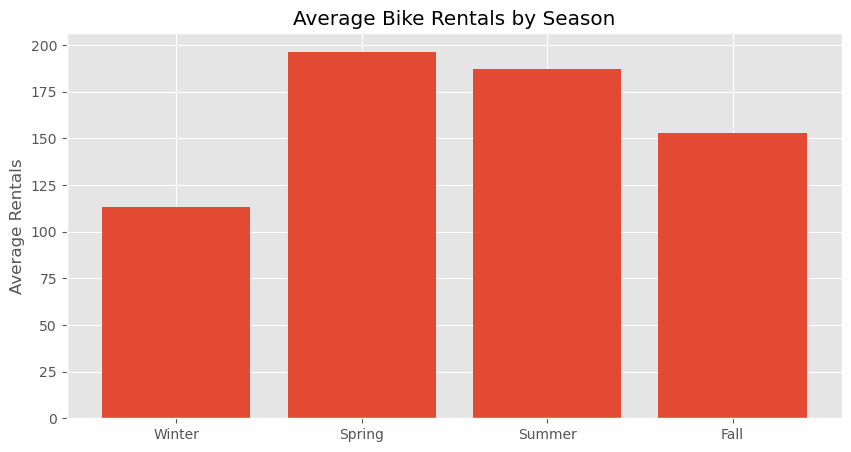

In [40]:
# Rentals by season
season_avg = train.groupby("season")["cnt"].mean()

season_labels = [
    "Winter",
    "Spring",
    "Summer",
    "Fall"
]

plt.figure(figsize=(10,5))

plt.bar(season_labels, season_avg)

plt.title("Average Bike Rentals by Season")
plt.ylabel("Average Rentals")

plt.show()

Bike rental activity differs substantially across seasons, with higher demand observed during warmer periods.

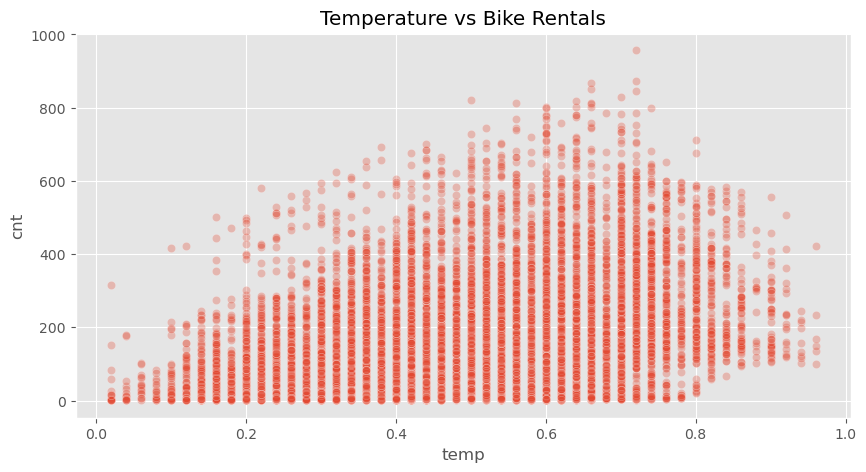

In [41]:
# Rentals vs temperature
plt.figure(figsize=(10,5))

sns.scatterplot(
    x="temp",
    y="cnt",
    data=train,
    alpha=0.3
)

plt.title("Temperature vs Bike Rentals")

plt.show()

A positive relationship can be observed between temperature and bike rental demand. Rental activity generally increases as temperature rises, indicating that users are more likely to use bike-sharing services during warmer weather conditions.

The highest rental volumes occur at moderate-to-high temperature levels, while extremely low temperatures are associated with substantially lower demand. However, the relationship is not perfectly linear, suggesting that additional factors such as weather conditions, time of day, and seasonality also influence rental behavior.

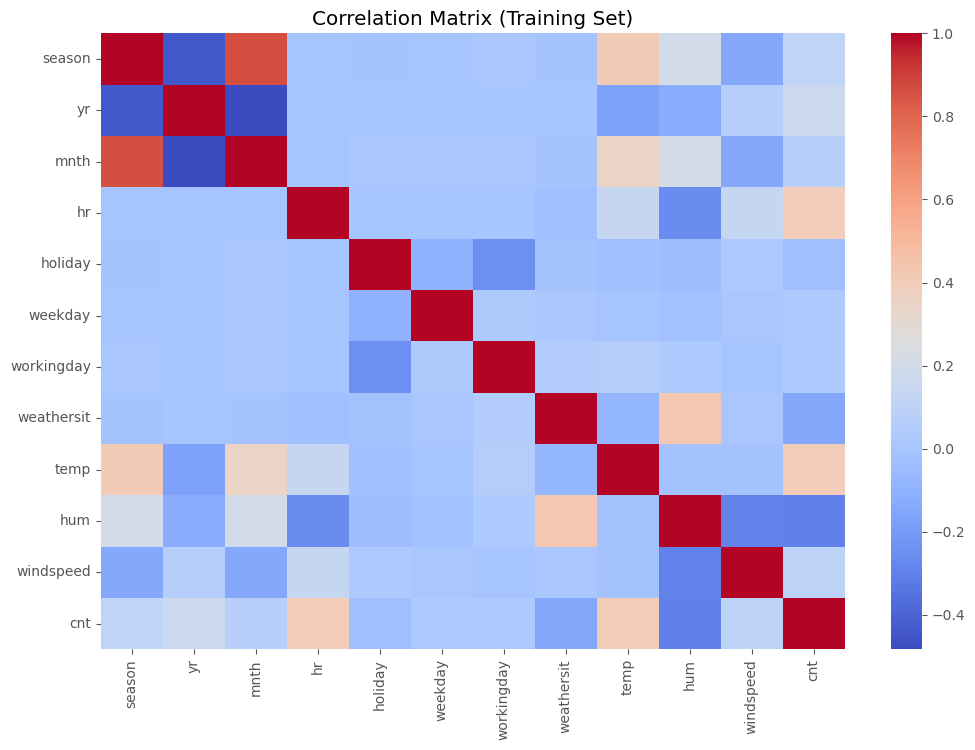

In [42]:
# Correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    train.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Matrix (Training Set)")

plt.show()

The correlation structure observed in the training subset is consistent with the patterns identified during the global exploratory analysis.

The target variable (`cnt`) exhibits moderate positive correlations with:
- `temp`,
- `hr`,
- and, to a lesser extent, seasonal variables.

This suggests that both weather conditions and temporal patterns play an important role in explaining bike rental demand.

Humidity (`hum`) and adverse weather conditions (`weathersit`) show negative relationships with the target variable, indicating reduced rental activity during less favorable environmental conditions.

Overall, the correlation analysis confirms that bike rental demand is influenced by a combination of temporal seasonality and weather-related factors.

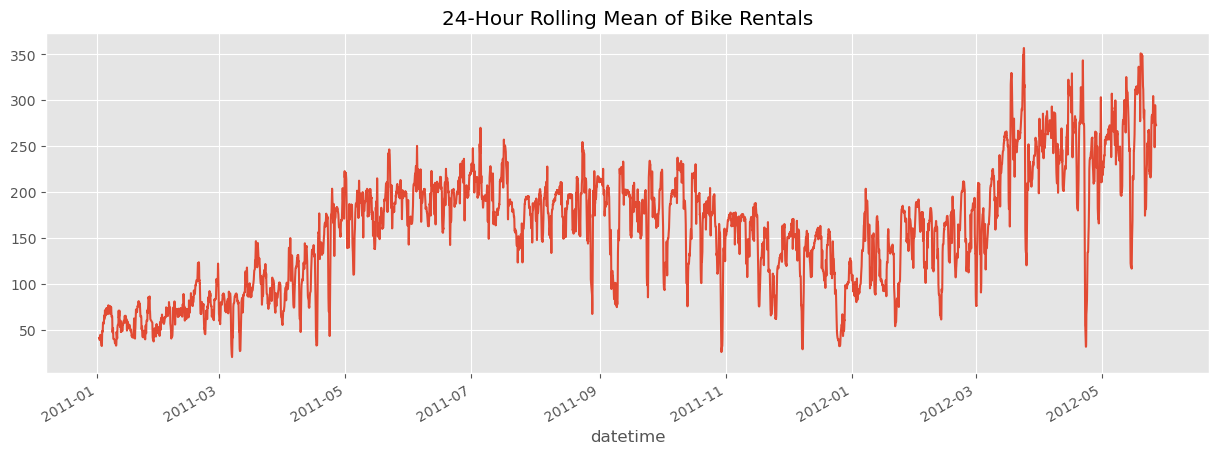

In [43]:
# Rolling mean
plt.figure(figsize=(15,5))

train["cnt"].rolling(24).mean().plot()

plt.title("24-Hour Rolling Mean of Bike Rentals")

plt.show()

The 24-hour rolling mean highlights the longer-term evolution of bike rental demand while smoothing short-term hourly fluctuations.

A gradual upward trend can be observed throughout the training period, indicating increasing adoption of the bike-sharing system over time. The rolling average also reveals clear seasonal effects, with lower demand during winter months and substantially higher activity during warmer periods.

Despite the smoothing effect of the rolling window, noticeable variability remains present, suggesting that the series retains significant temporal dynamics and short-term demand fluctuations.

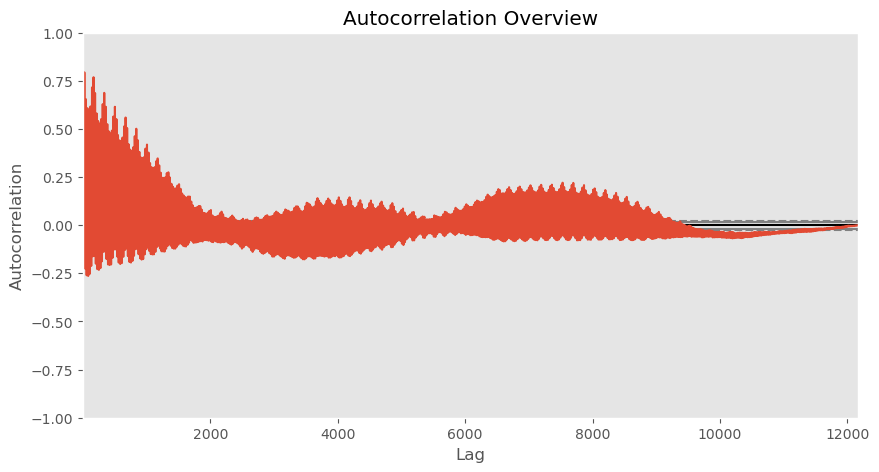

In [48]:
# Basic autocorrelation overview

plt.figure(figsize=(10,5))

autocorrelation_plot(train["cnt"])

plt.title("Autocorrelation Overview")

plt.show()

The autocorrelation analysis indicates strong temporal dependence within the series. High positive autocorrelation values are observed for smaller lags, suggesting that nearby observations are strongly related over time.

The oscillating autocorrelation structure also indicates the presence of recurring seasonal patterns, which is consistent with the daily demand cycles identified in the previous exploratory analysis.

Overall, the results confirm that bike rental demand exhibits substantial time dependency and non-random temporal structure, making the dataset suitable for forecasting applications.

### EDA Summary

The exploratory analysis revealed several important characteristics of the bike rental dataset:

- strong intra-day seasonality with pronounced commuting-hour demand peaks,
- moderate weekly seasonality,
- clear long-term trend growth between 2011 and 2012,
- substantial influence of weather and temperature on rental demand,
- strong temporal dependence and autocorrelation within the series.

The preprocessing stage also identified:
- missing hourly timestamps,
- highly correlated variables,
- and potential target leakage variables (`casual` and `registered`).

After preprocessing, the dataset was chronologically divided into training, validation, and test subsets to ensure proper forecasting evaluation and reproducibility.

The resulting processed dataset is now ready for baseline forecasting experiments and advanced modeling approaches.